# TP2 : Estimation de densité par noyaux

## G3 SDI - Introduction à l'Estimation Statistique

Dans le cadre de cours, nous avons étudié jusqu'à présent des méthodes d'estimation dites paramétriques : on se fixe une famille de lois paramétrique à laquelle la loi ayant généré les données est censée appartenir, puis on cherche à estimer les paramètres à partir des données (par exemple par maximum de vraisemblance).

Dans ce TP, nous introduisons une méthode d'estimation **non-paramétrique** de la fonction de densité appelée estimation par noyaux (*kernel estimation* en anglais). C'est-à-dire que nous ne faisons plus d'hypothèse sur la loi ayant généré les données, et nous cherchons plutôt à estimer directement la densité de la loi parente $f$ (que l'on supposera continue). Ainsi cette méthode ne concerne que les variables aléatoires continues.

### Instructions

1. Renommez votre notebook sous la forme `tp2_Nom1_Nom2.ipynb`. 

2. Votre code et les résultats obtenus doivent être commentés !

3. Déposez votre notebook sur Moodle dans la section prévue à cet effet avant la date limite.

**Compte rendu — Ugo Roccamatisi.**


In [2]:
import numpy as np
from matplotlib import pyplot as plt
import scipy.stats as ss

### Partie 1 - Histogrammes

On considère $(x_1, ..., x_n)$ $n$ réalisations indépendantes d'une variable aléatoire réelle.

Soit $x_0 \in \mathbb{R}$ et $h > 0$. On partitionne la droite réelle en intervalles de même longueur $h$, aussi appelés *bins* :
$$\forall k \in \mathbb{Z},~B_k =~]x_0 + (k-1)h~;~x_0 + kh].$$

L'histogramme est une fonction constante par morceaux définie de la manière suivante :
$$\forall x \in B_k,~H_n(x) = n_k,$$
où $n_k$ est le nombre de réalisations appartenant à l'intervalle $B_k$.

**Q1**. Comment normaliser $H_n$ pour obtenir un estimateur de la fonction de densité ? On rappelera que $\int_{\mathbb{R}} f(x) dx = 1$.

Dans la suite, on note $\hat{f}_n$ cet estimateur de $f$.

**Réponse.** Chaque classe de largeur $h$ a une aire $n_k h$ dans l’histogramme brut. Comme $\sum_k n_k=n$, la densité estimée vaut $\hat f_n(x)=n_k/(nh)$ pour $x\in B_k$ ; ainsi $\int \hat f_n(x)\,dx=1$.


**Q2 (bonus).** Pour tout $x \in \mathbb{R}$, calculer le biais et la variance de $\hat{f}_n(x)$. Commenter.

**Réponse (bonus).** Pour un $x$ fixé dans la classe $B_k$, poser $p_k=P(X\in B_k)=\int_{B_k}f(u)\,du$. Comme $n_k\sim\mathrm{Binom}(n,p_k)$, $E[\hat f_n(x)]=p_k/h$, d’où le biais **exact** $p_k/h-f(x)$ et la variance **exacte** $p_k(1-p_k)/(nh^2)$. Si $h\to0$, l’espérance tend vers $f(x)$ aux points de continuité ; la variance est d’ordre $1/(nh)$. Il faut donc à la fois $h\to0$ et $nh\to\infty$.

**Q3**. On fixe $x_0 = \min_i x_i$. La valeur de $h$ peut être fixée indirectement en fixant à la place le nombre de *bins* $N_b$ entre $\min_i x_i$ et $\max_i x_i$, on a alors
$$h = \frac{\max_i x_i - \min_i x_i}{N_b}.$$

Générer 200 points d'un modèle de mélange gaussien 1D à 2 composantes avec $\mu_1 = -2.5, \mu_2 = 1.5, \sigma_1 = \sigma_2 = 1, \pi_1 = 0.4, \pi_2 = 0.6$.

Montrer l'influence de la valeur de $h$ sur l'histogramme normalisé (prendre les valeurs de Nb suggérées dans la cellule de code).

On utilisera la fonction `np.histogram` pour calculer automatiquement les $n_k$, et la fonction `plt.bar` pour représenter $\hat{f}_n$. Superposer la densité théorique du modèle de mélange gaussien. Commenter.

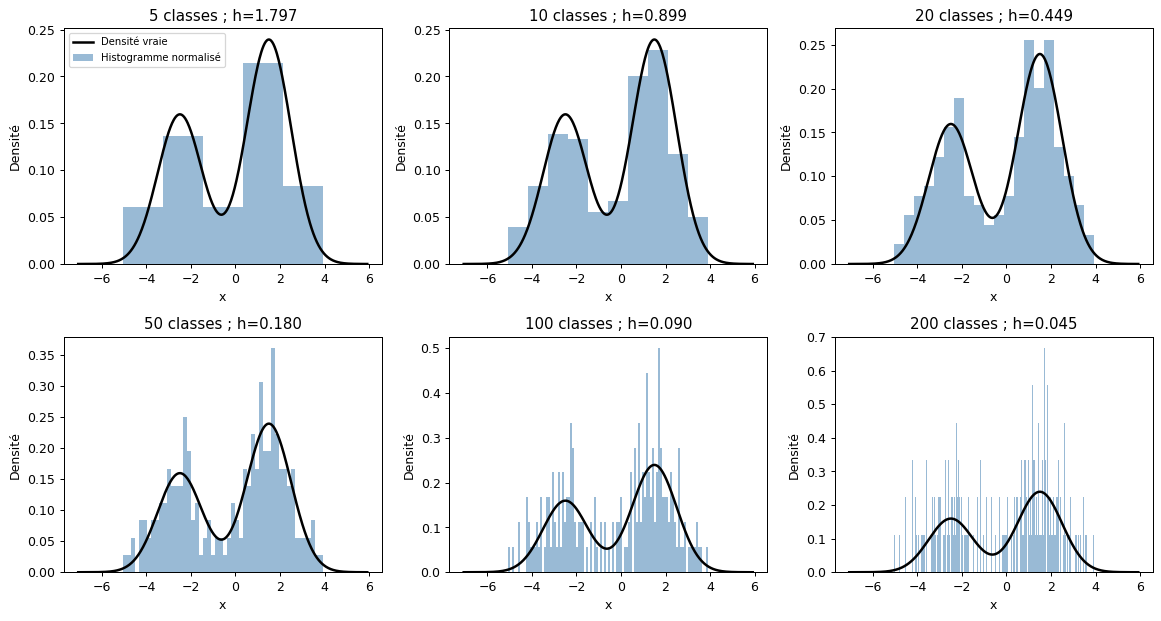

In [9]:
# Tirage reproductible : première composante de probabilité 0,4.
rng=np.random.default_rng(42)
N=200;Nb_list=[5,10,20,50,100,200]
labels=rng.random(N)<.4
sample=np.where(labels,rng.normal(-2.5,1,N),rng.normal(1.5,1,N))
xgrid=np.linspace(sample.min()-2,sample.max()+2,500)
true_density=.4*ss.norm.pdf(xgrid,-2.5,1)+.6*ss.norm.pdf(xgrid,1.5,1)
fig,axes=plt.subplots(2,3,figsize=(13,7))
for ax,nb in zip(axes.flat,Nb_list):
    counts,edges=np.histogram(sample,bins=nb,range=(sample.min(),sample.max()))
    h=np.diff(edges)[0]
    ax.bar(edges[:-1],counts/(N*h),width=h,align='edge',color='steelblue',alpha=.55,label='Histogramme normalisé')
    ax.plot(xgrid,true_density,'k',lw=2,label='Densité vraie')
    ax.set(title=f'{nb} classes ; h={h:.3f}',xlabel='x',ylabel='Densité')
axes.flat[0].legend(fontsize=8);fig.tight_layout();plt.show()

**Réponse.** Peu de classes : les deux modes peuvent se confondre et la courbe est trop lisse. Trop de classes : les effectifs par classe sont faibles, ce qui donne une estimation très irrégulière. Le nombre intermédiaire permet de mieux percevoir les deux bosses.

**Q4**. Quelles sont les principales limitations de l'utilisation de l'histogramme comme estimateur de la fonction de densité ?

**Réponse.** L’histogramme est discontinu et dépend du choix de la largeur et de l’origine des classes ; sa valeur peut changer si l’on déplace légèrement les bornes. En plusieurs dimensions, les cases deviennent nombreuses et souvent presque vides.

### Partie 2 - Estimation par noyaux en 1D

$(x_1, ..., x_n)$ sont toujours $n$ réalisations indépendantes d'une variable aléatoire réelle.

L'une des motivations principales est de faire directement dépendre l'estimation des données, et de ne plus dépendre de découpages arbitraires de $\mathbb{R}$. Pour cela, on propose la méthodologie suivante :
- Choisir une fonction $K$ appelée "noyau". On choisit $K$ positive ou nulle, symétrique, et d'intégrale 1.
- Centrer $K$ sur chaque observation $x_i$.
- L'estimateur à noyaux est alors
$$\hat{f}_n(x) = \frac{1}{n} \sum_{i=1}^n K(x - x_i).$$

On pourra par exemple choisir des noyaux $K$ continus, dérivables partout... Propriétés dont $\hat{f}_n$ héritera.

**Q1**. On utilise dans un premier temps un noyau gaussien :
$$K(x) = \frac{1}{\sqrt{2 \pi}} \exp \left( -\frac{x^2}{2} \right).$$

Prendre 10 observations des données générées dans la partie 1. Sur un même graphique, représenter les 10 noyaux (normalisés par $n$) centrés sur les observations, et l'estimateur à noyaux $\hat{f}_n$. Superposer la vraie densité $f$. Commenter.

Intégrale numérique estimée : 0.9997424464211063


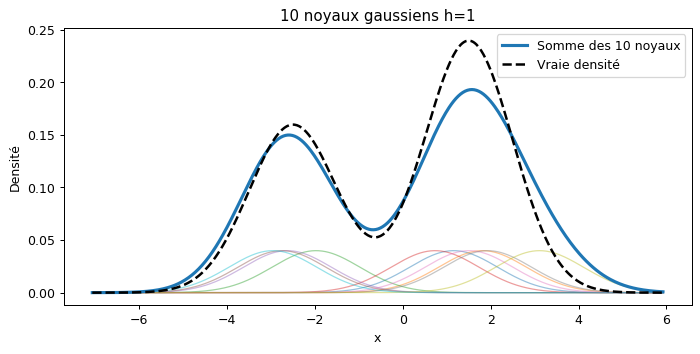

In [15]:
# Dix observations distinctes ; ici h=1, soit le noyau de la question.
ten=sample[rng.choice(N,size=10,replace=False)]
kernels=ss.norm.pdf(xgrid[:,None],loc=ten[None,:],scale=1)/10
estimated=kernels.sum(axis=1)
fig,ax=plt.subplots(figsize=(9,4))
for i in range(10):ax.plot(xgrid,kernels[:,i],alpha=.45,lw=1)
ax.plot(xgrid,estimated,label='Somme des 10 noyaux',lw=2.5)
ax.plot(xgrid,true_density,'k--',label='Vraie densité',lw=2)
ax.set(xlabel='x',ylabel='Densité',title='10 noyaux gaussiens h=1');ax.legend();plt.show()
print('Intégrale numérique estimée :',np.trapezoid(estimated,xgrid))

**Réponse.** Chaque point contribue une petite densité centrée sur lui ; leur somme (10 noyaux divisés chacun par 10) est une densité lisse d’intégrale 1. Avec seulement 10 observations, elle reste moins fidèle à la densité théorique que celle construite avec 200 points.

**Q2**. En réalité, on va faire dépendre cet estimateur d'un paramètre de lissage $h > 0$, qu'on appelle largeur de fenêtre (ou *bandwidth* en anglais).

Le (véritable) estimateur à noyaux, aussi appelé méthode de Parzen-Rosenblatt (du nom des deux statisticiens l'ayant développée) est :
$$\hat{f}_n(x) = \frac{1}{nh} \sum_{i=1}^n K(\frac{x - x_i}{h}).$$

(On peut facilement vérifier que $\hat{f}_n(x)$ intègre bien à 1).

Implémenter cet estimateur sur les données générées dans la partie 1, et montrer l'influence de la valeur de $h$. Commenter.

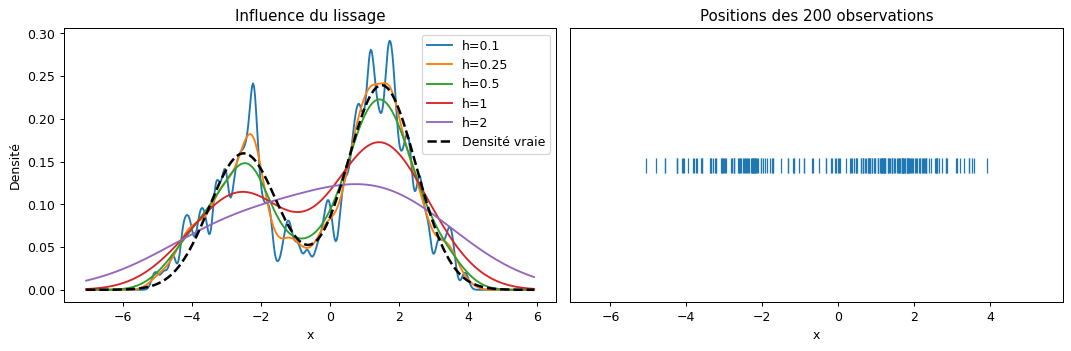

In [18]:
def gaussian_kde_1d(grid,sample,h):
    # N(x_i,h²), intégré à 1 ; moyenne sur tous les points observés.
    return ss.norm.pdf((grid[:,None]-sample[None,:])/h).mean(axis=1)/h
bandwidths=[.1,.25,.5,1,2]
fig,axes=plt.subplots(1,2,figsize=(12,4))
for h in bandwidths:axes[0].plot(xgrid,gaussian_kde_1d(xgrid,sample,h),label=f'h={h}')
axes[0].plot(xgrid,true_density,'k--',lw=2,label='Densité vraie');axes[0].legend()
axes[0].set(xlabel='x',ylabel='Densité',title='Influence du lissage')
axes[1].plot(sample,np.zeros_like(sample),'|',ms=12)
axes[1].set(xlim=(xgrid.min(),xgrid.max()),yticks=[],xlabel='x',title='Positions des 200 observations')
fig.tight_layout();plt.show()

**Réponse.** Un petit h donne des pics proches des observations : faible biais local mais forte variabilité. Un grand h lisse les fluctuations, au risque de fusionner les deux modes : biais plus élevé. La courbe noire est la vraie densité, disponible ici uniquement parce que les données ont été simulées.

**Q3.** Nous allons maintenant regarder d'autres noyaux. Cette fois-ci, nous n'implémenterons pas l'estimateur à la main mais ferons appel à la librairie `scikit-learn` qui implémente six noyaux différents (dont le noyau gaussien). La méthode est implémentée dans `sklearn.neighbors.KernelDensity` (voir la doc [ici](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KernelDensity.html)).

Représenter les six noyaux. Commenter.

À longueur de fenêtre fixée (par exemple $h = 0.5$), montrer l'influence des différentes fenêtres. Commenter.

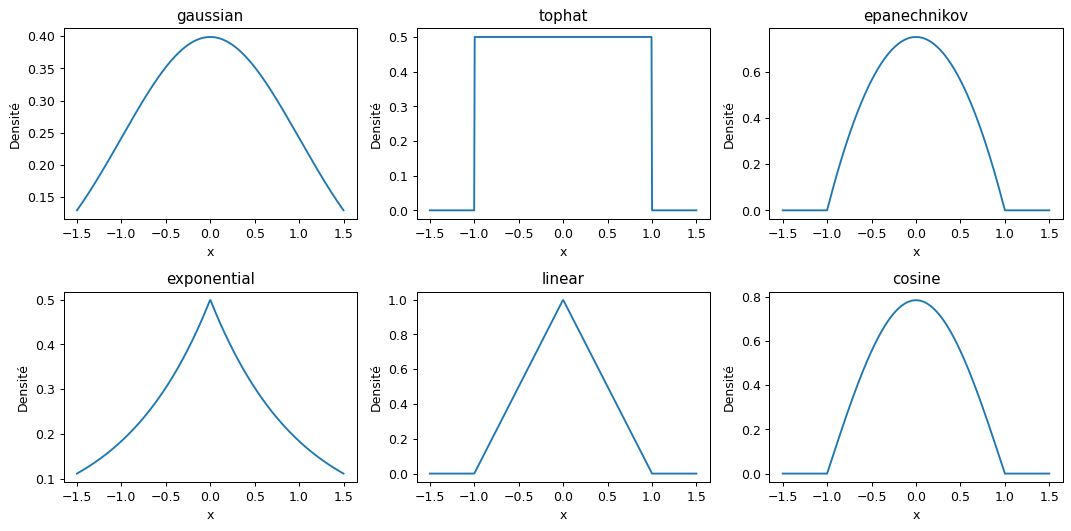

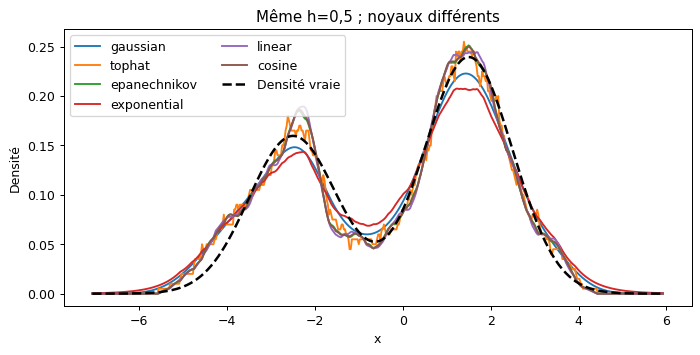

In [21]:
from sklearn.neighbors import KernelDensity
# Six noyaux compatibles avec sklearn.neighbors.KernelDensity.
kernel_names=['gaussian','tophat','epanechnikov','exponential','linear','cosine']
grid_kernel=np.linspace(-1.5,1.5,500)[:,None]
fig,axes=plt.subplots(2,3,figsize=(12,6))
for ax,name in zip(axes.flat,kernel_names):
    model=KernelDensity(kernel=name,bandwidth=1).fit(np.array([[0.0]]))
    ax.plot(grid_kernel[:,0],np.exp(model.score_samples(grid_kernel)))
    ax.set(title=name,xlabel='x',ylabel='Densité')
fig.tight_layout();plt.show()
fig,ax=plt.subplots(figsize=(9,4));h=.5
for name in kernel_names:
    model=KernelDensity(kernel=name,bandwidth=h).fit(sample[:,None])
    ax.plot(xgrid,np.exp(model.score_samples(xgrid[:,None])),label=name)
ax.plot(xgrid,true_density,'k--',lw=2,label='Densité vraie')
ax.set(xlabel='x',ylabel='Densité',title='Même h=0,5 ; noyaux différents');ax.legend(ncol=2);plt.show()

**Réponse.** Les six noyaux ont des profils distincts, notamment un support borné ou non. À h fixé, ils produisent ici des courbes différentes, mais le choix de h a souvent un impact visuel plus grand. Les noyaux non gaussiens peuvent présenter des cassures selon leur forme.

**Q4 (bonus)**. La question du choix de $h$ a été largement étudiée dans la littérature. Par exemple, la librairie `scikit-learn` embarque pour l'argument *bandwidth* deux règles de calcul empiriques appelées règle de Scott et règle de Silvermann, qui fixent la valeur de $h$ en fonction de $n$ et $d$ (la dimension des données).

À l'aide d'une notion du cours, pouvez-vous imaginer un critère d'optimalité permettant de fixer la valeur de $h$ ?

**Réponse (bonus).** On peut choisir $h$ en maximisant la **log-vraisemblance prédictive en validation croisée** : pour chaque pli, ajuster la KDE sur les autres plis et sommer les log-densités des observations du pli tenu à l’écart. Un petit $h$ sur-apprend et un grand $h$ sous-ajuste. Évaluer la vraisemblance sur les mêmes points que ceux qui servent à l’ajustement favoriserait à tort $h\to0$.

### Partie 3 : Estimation par noyaux en 2D

L'estimation de densité par noyaux peut être étendue en $d$ dimensions. On peut alors définir $\mathbf{H}$ une matrice symmétrique de taille $d \times d$ définie positive pour les longueurs de fenêtres (NB : `scikit-learn` ne le permet pas et n'a qu'un paramètre scalaire en $d$ dimensions).

**Q1**. Reprendre le dataset *Old Faithful* étudié au TP1, et faire une estimation par noyaux de la densité en utilisant `scikit-learn`. Le choix du noyau et de la longueur de fenêtre est laissé libre.

Afficher la densité obtenue. On pourra par exemple la représenter sous forme de *heatmap* avec `plt.imshow`, ou bien sous la forme d'un *surface plot* (exemple [ici](https://matplotlib.org/stable/gallery/mplot3d/surface3d.html)). Commenter.

Taille Old Faithful : (272, 2)


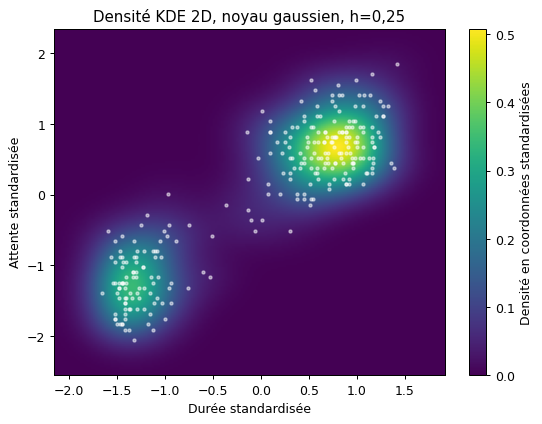

In [27]:
# Dataset joint au TP1, copié ici pour exécuter le TP2 hors ligne.
from pathlib import Path
from sklearn.preprocessing import StandardScaler
geyser=np.load(Path('oldfaithful.npy'))
scaler=StandardScaler().fit(geyser);X_geyser=scaler.transform(geyser)
kde_2d=KernelDensity(kernel='gaussian',bandwidth=.25).fit(X_geyser)
xv,yv=np.meshgrid(np.linspace(X_geyser[:,0].min()-.5,X_geyser[:,0].max()+.5,180),np.linspace(X_geyser[:,1].min()-.5,X_geyser[:,1].max()+.5,180))
grid2=np.c_[xv.ravel(),yv.ravel()]
z=np.exp(kde_2d.score_samples(grid2)).reshape(xv.shape)
fig,ax=plt.subplots(figsize=(7,5))
im=ax.imshow(z,origin='lower',extent=[xv.min(),xv.max(),yv.min(),yv.max()],aspect='auto',cmap='viridis')
ax.scatter(*X_geyser.T,c='white',s=6,alpha=.5)
ax.set(xlabel='Durée standardisée',ylabel='Attente standardisée',title='Densité KDE 2D, noyau gaussien, h=0,25')
fig.colorbar(im,ax=ax,label='Densité en coordonnées standardisées');plt.show()
print('Taille Old Faithful :',geyser.shape)

**Réponse.** La standardisation donne une importance comparable à la durée et à l’attente, exprimées initialement dans des unités d’échelle différente. La carte met en évidence deux zones de forte densité ; un noyau gaussien donne des contours lisses sans imposer exactement deux composantes.

### Partie 4 : Estimation par noyaux en 64D ! Un modèle génératif

Une fois la fonction de densité estimée par noyaux, nous pouvons échantillonner de cette loi. Ceci nous permet donc de générer "de fausses données". C'est ce que nous allons mettre en oeuvre sur un exemple simple avec des images. Estimer la densité nous permettra donc de créer un générateur d'images.


**Q1.** Pour cette dernière question, nous utiliserons le dataset *Digits* qui contient environ 1800 imagettes en niveaux de gris de taille 8 par 8, qui peuvent donc être représentées comme des vecteurs de taille 64. Ces imagettes représentent des numéros scannés de codes postaux.

- Estimer par noyaux de la densité en utilisant `scikit-learn`. Le choix du noyau et de la longueur de fenêtre sont laissés libres.
- Afficher 10 images du dataset, puis 10 images échantillonnées à partir de la loi estimée. On utilisera la méthode `.sample`.
- Commenter.

Dimensions : (1797, 64) ; plage des échantillons avant affichage : -3.889520808082887 18.51086473082255


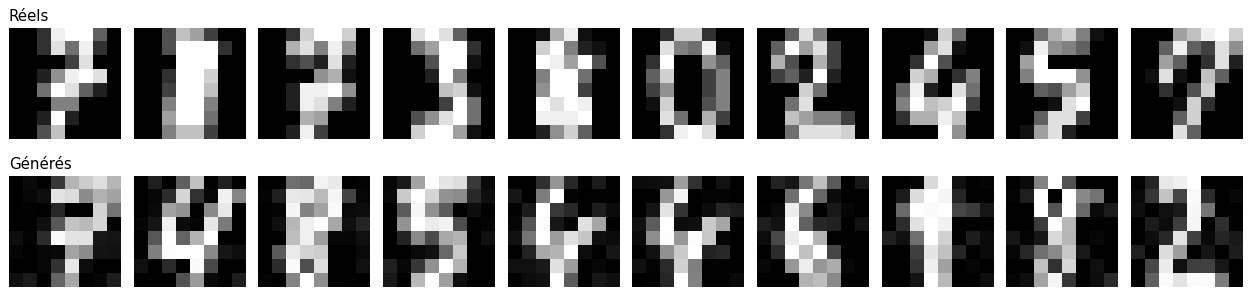

In [32]:
from sklearn.datasets import load_digits
X_digits=load_digits().data.astype(float)
# Bande passante en intensités brutes des pixels (0 à 16).
digits_kde=KernelDensity(kernel='gaussian',bandwidth=1.2).fit(X_digits)
new_digits=digits_kde.sample(10,random_state=42)
rng_display=np.random.default_rng(1)
real_indices=rng_display.choice(len(X_digits),10,replace=False)
fig,axes=plt.subplots(2,10,figsize=(14,3.6))
for i in range(10):
    axes[0,i].imshow(X_digits[real_indices[i]].reshape(8,8),cmap='gray',vmin=0,vmax=16)
    # L'écrêtage ne sert qu'à l'affichage ; le modèle gaussien peut produire
    # des valeurs < 0 ou > 16, hors du domaine physique des pixels.
    axes[1,i].imshow(np.clip(new_digits[i],0,16).reshape(8,8),cmap='gray',vmin=0,vmax=16)
    for row in axes:row[i].axis('off')
axes[0,0].set_title('Réels',loc='left');axes[1,0].set_title('Générés',loc='left')
fig.tight_layout();plt.show()
print('Dimensions :',X_digits.shape,'; plage des échantillons avant affichage :',new_digits.min(),new_digits.max())

**Réponse.** Une KDE gaussienne en 64 dimensions génère approximativement une image d’entraînement à laquelle on ajoute du bruit gaussien à chaque pixel. Les chiffres ressemblent donc généralement à des exemples existants, parfois avec du grain ; les intensités simulées peuvent dépasser [0,16] et sont écrêtées **uniquement pour la figure**. En grande dimension, estimer fidèlement une densité demanderait beaucoup plus de données.